In [54]:
import warnings

warnings.filterwarnings("ignore")

In [55]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [56]:
import os
from dotenv import load_dotenv
load_dotenv()
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GROQ_API_KEY"]= GROQ_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [57]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

from langchain_groq import ChatGroq
llm = ChatGroq(model_name="llama-3.3-70b-versatile")
llm.invoke("hi").content

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

In [58]:
llm.invoke("hello how are you?")

AIMessage(content="Hello, I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How about you? How's your day going so far?", response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 40, 'total_tokens': 102, 'completion_time': 0.120839065, 'completion_tokens_details': None, 'prompt_time': 0.002203181, 'prompt_tokens_details': None, 'queue_time': 0.048381359, 'total_time': 0.123042246}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'finish_reason': 'stop', 'logprobs': None}, id='run-0aa42b6a-1a50-4cd3-a77e-29baef3ae4da-0', usage_metadata={'input_tokens': 40, 'output_tokens': 62, 'total_tokens': 102})

In [59]:

url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [60]:
WebBaseLoader(url).load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [61]:
WebBaseLoader(url).load()[0].metadata["description"]

'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model 

In [62]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [63]:
docs = [WebBaseLoader(url).load() for url in urls]

In [64]:
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [65]:
docs_list=[item for sublist in docs for item in sublist]

In [66]:
docs_list

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [67]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=25)

In [68]:
doc_splits=text_splitter.split_documents(docs_list)

In [69]:
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [70]:
len(doc_splits)

287

In [71]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chrome",
    embedding=embeddings
    
)

In [72]:
retriever=vectorstore.as_retriever()

In [73]:
result = retriever.invoke("Chain of Hindsight?")
print(result)

[Document(metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utiliz

In [74]:
print(result[0].page_content)

Chain of Hindsight (CoH; Liu et al. 2023) encourages the model to improve on its own outputs by explicitly presenting it with a sequence of past outputs, each annotated with feedback. Human feedback data is a collection of $D_h = \{(x, y_i , r_i , z_i)\}_{i=1}^n$, where $x$ is the prompt, each $y_i$ is a model completion,


In [75]:
retriever_tool=create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.",
    )

In [76]:
tools=[retriever_tool]

In [77]:
new_result = retriever_tool.invoke("Chain of Hindsight?")
print(new_result)

Chain of Hindsight (CoH; Liu et al. 2023) encourages the model to improve on its own outputs by explicitly presenting it with a sequence of past outputs, each annotated with feedback. Human feedback data is a collection of $D_h = \{(x, y_i , r_i , z_i)\}_{i=1}^n$, where $x$ is the prompt, each $y_i$ is a model completion,

Chain of Hindsight (CoH; Liu et al. 2023) encourages the model to improve on its own outputs by explicitly presenting it with a sequence of past outputs, each annotated with feedback. Human feedback data is a collection of $D_h = \{(x, y_i , r_i , z_i)\}_{i=1}^n$, where $x$ is the prompt, each $y_i$ is a model completion,

[2] Yao et al. “Tree of Thoughts: Dliberate Problem Solving with Large Language Models.” arXiv preprint arXiv:2305.10601 (2023).
[3] Liu et al. “Chain of Hindsight Aligns Language Models with Feedback
“ arXiv preprint arXiv:2302.02676 (2023).

[2] Yao et al. “Tree of Thoughts: Dliberate Problem Solving with Large Language Models.” arXiv preprint ar

In [78]:

retrieve=ToolNode([retriever_tool])

## Now creating state using Class and all functions

In [118]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    retries: int  # ← add this

In [119]:
def ai_assistant(state:AgentState):
    print("---CALL AGENT---")
    messages = state['messages']
    
    
    llm_with_tool = llm.bind_tools(tools)
    response = llm_with_tool.invoke(messages)
    #response=handle_query(messages)
    return {"messages": [response]}

In [120]:
class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'yes' or 'no'")

In [121]:
def grade_documents(state:AgentState)->Literal["Output_Generator", "Query_Rewriter"]:
    llm_with_structure_op=llm.with_structured_output(grade)
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user’s question.
                    Here is the document: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
    chain = prompt | llm_with_structure_op
    
    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator" #this should be a node name
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewriter" #this should be a node name

In [122]:
prompt = hub.pull("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [123]:
def generate(state:AgentState):
    print("---GENERATE---")
    messages = state["messages"]

    question = messages[0].content
    
    last_message = messages[-1]
    docs = last_message.content
    
    prompt = hub.pull("rlm/rag-prompt")
    
    rag_chain = prompt | llm

    response = rag_chain.invoke({"context": docs, "question": question})
    print(f"this is my response:{response}")
    
    return {"messages": [response]}

In [124]:
from langchain_core.messages import  HumanMessage
def rewrite(state:AgentState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content
    
    message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response = llm.invoke(message)
    return {"messages": [response]}

In [125]:
def transform_query(state: AgentState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    retries = state.get("retries", 0)

    if retries >= 2:
        print("---MAX RETRIES REACHED---")
        return {"messages": messages, "retries": retries}
    
    # rewrite the question
    last_message = messages[-1]
    better_question = question_rewriter.invoke({"question": last_message.content})
    return {"messages": [HumanMessage(content=better_question)], "retries": retries + 1}

In [126]:
workflow=StateGraph(AgentState)
workflow.add_node("My_Ai_Assistant",ai_assistant)
workflow.add_node("Vector_Retriever", retrieve) 
workflow.add_node("Output_Generator", generate)
workflow.add_node("Query_Rewriter", rewrite) 

In [127]:
workflow.add_edge(START,"My_Ai_Assistant")
workflow.add_conditional_edges("My_Ai_Assistant",
                            tools_condition,
                            {"tools": "Vector_Retriever",
                                END: END,})
workflow.add_conditional_edges("Vector_Retriever",
                            grade_documents,
                            {"generator": "Output_Generator",
                            "rewriter": "Query_Rewriter"
                            }
                            )

workflow.add_edge("Output_Generator", END)
workflow.add_edge("Query_Rewriter", "My_Ai_Assistant")
app=workflow.compile()

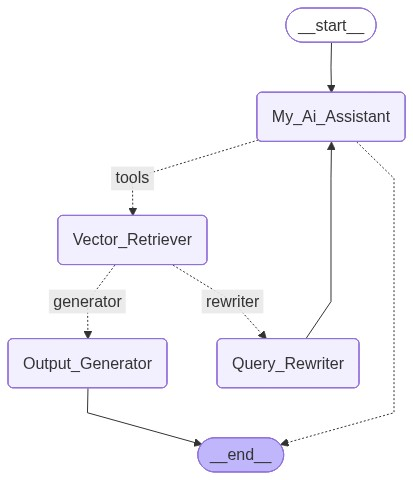

In [128]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [129]:
app.invoke({"messages":["What is a Autonomous Agent?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='What is a Autonomous Agent?', id='d35243dd-f51b-42fe-a227-bd2f8f3ce311'),
  AIMessage(content='An autonomous agent is a system or entity that can operate independently, making decisions and taking actions without direct human intervention. Autonomous agents can be found in various fields, including robotics, artificial intelligence, economics, and biology. They are typically characterized by their ability to perceive their environment, reason about the current state, and adapt to changes or new information.\n\nIn the context of artificial intelligence, an autonomous agent is a program or system that can perform tasks on its own, using techniques such as machine learning, planning, and decision-making. Autonomous agents can be designed to achieve specific goals, such as navigating a physical space, playing games, or optimizing a process.\n\nSome key features of autonomous agents include:\n\n1. Autonomy: The ability to operate independently, without hu

In [130]:
app.invoke({"messages":["what is a prompt engineering explain me in terms of agents and langchain?"]})

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response:content="In the context of agents and LangChain, prompt engineering refers to the methods used to communicate with Large Language Models (LLMs) to achieve desired outcomes. This is done through In-Context Prompting, which involves crafting input prompts to steer the LLM's behavior without updating its model weights. By using effective prompt engineering techniques, agents like AutoGPT and GPT-Engineer can be built to solve general problems and generate desired outputs." response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 396, 'total_tokens': 486, 'completion_time': 0.293938121, 'completion_tokens_details': None, 'prompt_time': 0.020177762, 'prompt_tokens_details': None, 'queue_time': 0.049420877, 'total_time': 0.314115883}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'finish_reason': 'stop', 'logprobs': None} id='run-397782e3-55db-4e13-9e8a-816d

{'messages': [HumanMessage(content='what is a prompt engineering explain me in terms of agents and langchain?', id='9a41182a-da8a-4b40-b0f7-0ea5305328f8'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ptd4pdvew', 'function': {'arguments': '{"query":"prompt engineering agents LangChain"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 401, 'total_tokens': 421, 'completion_time': 0.066054724, 'completion_tokens_details': None, 'prompt_time': 0.02056157, 'prompt_tokens_details': None, 'queue_time': 0.04755531, 'total_time': 0.086616294}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-205da622-e71c-4d24-b9eb-7980afa5a1d2-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'prompt engineering agents LangChain'}, 'id': 'ptd4pdvew', 'type': 'tool_call'}], usage_metadata={'input_tokens

In [131]:
app.invoke({"messages":["what is capital of india?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='what is capital of india?', id='714f70b3-b34a-489f-9b71-450b069328f3'),
  AIMessage(content='The capital of India is New Delhi.', response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 392, 'total_tokens': 401, 'completion_time': 0.018474628, 'completion_tokens_details': None, 'prompt_time': 0.039675444, 'prompt_tokens_details': None, 'queue_time': 0.048068026, 'total_time': 0.058150072}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'finish_reason': 'stop', 'logprobs': None}, id='run-649cfd4a-dd92-4ec8-b4ed-d6027bf4140c-0', usage_metadata={'input_tokens': 392, 'output_tokens': 9, 'total_tokens': 401})]}

In [132]:
app.invoke({"messages": ["what does the document say about agent memory?"]})

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response:content='The document mentions that agent memory is a component of the agent system, specifically Component Two, which includes types of memory and Maximum Inner Product Search (MIPS). It also states that generative agents combine memory with other mechanisms to enable conditioned behavior based on past experience. The document does not provide further details about the specifics of agent memory beyond these points.' response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 306, 'total_tokens': 377, 'completion_time': 0.224659799, 'completion_tokens_details': None, 'prompt_time': 0.017969686, 'prompt_tokens_details': None, 'queue_time': 0.048136484, 'total_time': 0.242629485}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'finish_reason': 'stop', 'logprobs': None} id='run-5a26b21c-f438-48b8-ac8b-e088fa4897e5-0' usage_metadata={'input_tokens': 306, 'outp

{'messages': [HumanMessage(content='what does the document say about agent memory?', id='b504b60f-b360-4892-b37f-2d8b2c141370'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jmsvjec85', 'function': {'arguments': '{"query":"agent memory"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 395, 'total_tokens': 412, 'completion_time': 0.043445972, 'completion_tokens_details': None, 'prompt_time': 0.019024416, 'prompt_tokens_details': None, 'queue_time': 0.160635263, 'total_time': 0.062470388}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-5d2c04c8-220d-4c7d-8025-5f25d651ff3d-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'agent memory'}, 'id': 'jmsvjec85', 'type': 'tool_call'}], usage_metadata={'input_tokens': 395, 'output_tokens': 17, 'total_tokens': 412}),
  ToolMessage(conte

In [133]:
result = app.invoke({"messages": ["what does the document say about agent memory?"]})
print(result["messages"][-1].content)

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response:content='The document mentions that agent memory is a component of the agent system, specifically Component Two, which includes types of memory and Maximum Inner Product Search (MIPS). The design of generative agents combines memory with other mechanisms to enable agents to behave conditioned on past experience. It does not provide further details on the specifics of agent memory beyond its inclusion as a component.' response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 306, 'total_tokens': 379, 'completion_time': 0.251758249, 'completion_tokens_details': None, 'prompt_time': 0.023175978, 'prompt_tokens_details': None, 'queue_time': 0.048685482, 'total_time': 0.274934227}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'finish_reason': 'stop', 'logprobs': None} id='run-cb23258b-e688-43fa-871c-3ab47c777417-0' usage_metadata={'input_tokens': 306, 'outp

In [134]:
result = app.invoke({"messages": ["waht iz agnt memoery?"]})
print(result["messages"][-1].content)

---CALL AGENT---
Agent memory refers to the ability of an artificial intelligence (AI) agent, such as a chatbot or a virtual assistant, to store and recall information about its interactions with users over time. This allows the agent to learn from its experiences, adapt to changing circumstances, and provide more personalized and effective responses to user queries.

In the context of large language models (LLMs), agent memory can be thought of as a mechanism that enables the model to retain information about its previous conversations, such as the topic of discussion, the user's preferences, and the context of the conversation. This information can be used to inform the model's responses and generate more coherent and relevant text.

Agent memory can be implemented in various ways, such as through the use of external memory mechanisms, like databases or knowledge graphs, or through the use of internal memory mechanisms, like recurrent neural networks (RNNs) or transformers. The goal 

In [135]:
app.invoke({"messages": ["what did they say about the memory stuff?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='what did they say about the memory stuff?', id='89f71b82-c5a5-4779-a40e-9e79976479e3'),
  AIMessage(content="I'm not sure what you're referring to. This conversation just started. If you could provide more context or information about what you're trying to remember, I'd be happy to try and help.", response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 395, 'total_tokens': 436, 'completion_time': 0.127764333, 'completion_tokens_details': None, 'prompt_time': 0.019948846, 'prompt_tokens_details': None, 'queue_time': 0.048505514, 'total_time': 0.147713179}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'finish_reason': 'stop', 'logprobs': None}, id='run-ee58c44b-733d-4b46-979e-81294fb1910d-0', usage_metadata={'input_tokens': 395, 'output_tokens': 41, 'total_tokens': 436})]}

In [136]:
app.invoke({"messages": ["huh what about memory?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='huh what about memory?', id='3fc547da-c7ae-439b-892f-f70c7ab963d3'),
  AIMessage(content="Memory can refer to different concepts depending on the context. In computing, memory typically refers to the temporary storage space where data is held while a computer is running. This can include random access memory (RAM) and other types of storage. In the context of human cognition, memory refers to the mental capacity to encode, store, and retrieve information. If you're asking about memory in relation to a specific topic, such as artificial intelligence or machine learning, could you provide more details so I can give a more precise answer?", response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 392, 'total_tokens': 497, 'completion_time': 0.386804153, 'completion_tokens_details': None, 'prompt_time': 0.028804841, 'prompt_tokens_details': None, 'queue_time': 0.049388248, 'total_time': 0.415608994}, 'model_name': 'llama-3.3-70b-vers

In [137]:
result = app.invoke({"messages": ["what does langsmith allow users to do?"]})
print(result["messages"][-1].content)

---CALL AGENT---
LangSmith is an AI platform that allows users to create, train, and fine-tune their own language models. It provides a range of tools and features that enable users to customize and adapt language models to their specific needs and applications. With LangSmith, users can:

1. Create and train custom language models: Users can train their own language models from scratch or fine-tune pre-trained models on their own datasets.
2. Fine-tune pre-trained models: LangSmith allows users to fine-tune pre-trained language models on their own datasets, enabling them to adapt the models to their specific use cases.
3. Customize model architecture: Users can customize the architecture of their language models, including the number of layers, attention mechanisms, and other hyperparameters.
4. Integrate with other tools and services: LangSmith provides APIs and integrations with other tools and services, enabling users to incorporate their custom language models into their own appli

In [138]:
result = app.invoke({"messages": ["what is the MIPS agent framework mentioned in lilianweng blog?"]})
print(result["messages"][-1].content)

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---
this is my response:content='The MIPS agent framework is mentioned in Lilian Weng\'s blog post "LLM-powered Autonomous Agents" as a type of agent framework. MIPS stands for "Modular, Incremental, Probabilistic, and Semantic", which are key characteristics of this framework. It is designed to work with large language models (LLMs) to create autonomous agents.' response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 320, 'total_tokens': 392, 'completion_time': 0.194958373, 'completion_tokens_details': None, 'prompt_time': 0.02298624, 'prompt_tokens_details': None, 'queue_time': 0.048263, 'total_time': 0.217944613}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'finish_reason': 'stop', 'logprobs': None} id='run-73234767-1308-409d-a571-942d0efb2c19-0' usage_metadata={'input_tokens': 320, 'output_tokens': 72, 'total_tokens': 392}
The MIPS agent framework is mentioned in Lilia